Within this notebook I attempt to show how Elon Musk's Tweets affect Tesla's stock price. 
Elon Musk has recently acquired Twitter and has an active presence on the website. After his acquisition, he implemented tougher data restrictions on twitter, so past methods such as using apis to scrape twitter are no longer publically available without consent of Twiter. I, of course, did not feel the need to pay the fee for Twitter's developer API and thus chose to use previously scraped Elon Musk tweets available on Kaggle to estimate the impacts of his tweets on Tesla's price. 
I used 2 models in order to see how this could be estimated and found that a simple linear regression that controls for the S&P 500 is effective at estimating this impact.


In [90]:
import requests
from bs4 import BeautifulSoup
import re
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from textblob import TextBlob
import os
import pandas as pd
from datetime import timedelta
import kaggle
from kaggle.api.kaggle_api_extended import KaggleApi
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split 
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [12]:
api = KaggleApi()
api.authenticate()
dataset_ref = "aryansingh0909/elon-musk-tweets-updated-daily"
api.dataset_download_files(dataset_ref, path="elon_musk_tweets", unzip=True)

Dataset URL: https://www.kaggle.com/datasets/aryansingh0909/elon-musk-tweets-updated-daily


In [14]:
files = os.listdir("elon_musk_tweets")
print("Files in dataset:", files)

Files in dataset: ['elonmusk.csv']


In [40]:
#DO NOT TOUCH. SUPER FINNICKY. WILL DESTROY PROJECT VIA RATE LIMIT THING. WILL RUIN YOUR MENTAL HEALTH. DO NOT TOUCH. I REPEAT. DO NOT TOUCH.



# Download historical stock data for Tesla (TSLA)
tickers = yf.download(["TSLA", "RIVN", "^GSPC"], start="2010-06-04", end="2023-06-29")


df2 = pd.DataFrame(tickers)


print(df2.head())
print(df2.columns)

# Select only the 'Close' prices for each stock
stocks = df2.xs('Close', level='Price', axis=1)

# Print the result
print(stocks.head())
print(stocks.columns)


[*********************100%***********************]  3 of 3 completed

Price      Close                   High                    Low       \
Ticker      RIVN TSLA        ^GSPC RIVN TSLA        ^GSPC RIVN TSLA   
Date                                                                  
2010-06-04   NaN  NaN  1064.880005  NaN  NaN  1098.430054  NaN  NaN   
2010-06-07   NaN  NaN  1050.469971  NaN  NaN  1071.359985  NaN  NaN   
2010-06-08   NaN  NaN  1062.000000  NaN  NaN  1063.150024  NaN  NaN   
2010-06-09   NaN  NaN  1055.689941  NaN  NaN  1077.739990  NaN  NaN   
2010-06-10   NaN  NaN  1086.839966  NaN  NaN  1087.849976  NaN  NaN   

Price                   Open                   Volume                   
Ticker            ^GSPC RIVN TSLA        ^GSPC   RIVN TSLA       ^GSPC  
Date                                                                    
2010-06-04  1060.500000  NaN  NaN  1098.430054    NaN  NaN  6180580000  
2010-06-07  1049.859985  NaN  NaN  1065.839966    NaN  NaN  5467560000  
2010-06-08  1042.170044  NaN  NaN  1050.810059    NaN  NaN  619275

In [42]:
for file in files:
    if file.endswith(".csv"):
        df = pd.read_csv(f"elon_musk_tweets/{file}")
        print("DataFrame loaded:")
        print(df.head())
        break

DataFrame loaded:
                    Datetime             Tweet Id  \
0  2023-06-29 16:20:19+00:00  1674452749378002945   
1  2023-06-29 15:53:52+00:00  1674446089179766789   
2  2023-06-29 03:46:37+00:00  1674263071337111552   
3  2023-06-29 01:19:59+00:00  1674226170488057856   
4  2023-06-28 18:05:58+00:00  1674116945808068608   

                                                Text  Username  
0                                      @mwseibel Yup  elonmusk  
1                                  @TitterDaily True  elonmusk  
2  @paulg Generational trauma. An example of why ...  elonmusk  
3                            Improved longform posts  elonmusk  
4                         @BillyM2k Best protip ever  elonmusk  


In [44]:
# Step 1: Convert to datetime
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')

# Step 1b: Remove timezone if already tz-aware
if df['Datetime'].dt.tz is not None:
    df['Datetime'] = df['Datetime'].dt.tz_convert(None)
else:
    df['Datetime'] = df['Datetime'].dt.tz_localize('UTC').dt.tz_convert(None)

# Step 2: Check for failed conversions
if df['Datetime'].isna().any():
    print("Warning: Some datetime values could not be parsed:")
    print(df[df['Datetime'].isna()])

# Step 3: Shift tweets posted after 5 PM to the next day
df['AdjustedDate'] = df['Datetime'].apply(
    lambda dt: dt.date() + timedelta(days=1) if pd.notnull(dt) and dt.hour >= 17 else (dt.date() if pd.notnull(dt) else pd.NaT)
)

# Step 4: Set adjusted date as index
df.set_index('AdjustedDate', inplace=True)
df.sort_index(inplace=True)

print(df.head())

                        Datetime            Tweet Id  \
AdjustedDate                                           
2010-06-05   2010-06-04 18:31:57         15434727182   
2011-12-01   2011-12-01 09:55:11  142179928203460608   
2011-12-01   2011-12-01 10:29:04  142188458125963264   
2011-12-03   2011-12-03 08:20:28  142880871391838208   
2011-12-03   2011-12-03 08:22:07  142881284019060736   

                                                           Text  Username  
AdjustedDate                                                               
2010-06-05    Please ignore prior tweets, as that was someon...  elonmusk  
2011-12-01    Went to Iceland on Sat to ride bumper cars on ...  elonmusk  
2011-12-01    I made the volume on the Model S http://t.co/w...  elonmusk  
2011-12-03    Great Voltaire quote, arguably better than Twa...  elonmusk  
2011-12-03                    That was a total non sequitur btw  elonmusk  


In [24]:
# Display column names
print(df.columns)

# Display data types of each column
print(df.dtypes)

# Display summary statistics
print(df.describe(include='all'))

Index(['Datetime', 'Tweet Id', 'Text', 'Username'], dtype='object')
Datetime    datetime64[ns, UTC]
Tweet Id                  int64
Text                     object
Username                 object
dtype: object
                                   Datetime      Tweet Id         Text  \
count                                 24450  2.445000e+04        24450   
unique                                  NaN           NaN        23778   
top                                     NaN           NaN  @BillyM2k 🤣   
freq                                    NaN           NaN           33   
mean    2020-10-06 21:27:24.161718016+00:00  1.313594e+18          NaN   
min               2010-06-04 18:31:57+00:00  1.543473e+10          NaN   
25%     2019-04-22 19:01:45.750000128+00:00  1.120402e+18          NaN   
50%               2021-05-07 02:22:01+00:00  1.390492e+18          NaN   
75%     2022-11-27 21:20:23.249999872+00:00  1.596977e+18          NaN   
max               2023-06-29 16:20:19+00:00  1.674

In [46]:

analyzer = SentimentIntensityAnalyzer()
df['vader_scores'] = df['Text'].apply(lambda x: analyzer.polarity_scores(str(x)))
df['compound'] = df['vader_scores'].apply(lambda score: score['compound'])
df['sentiment'] = df['compound'].apply(
    lambda c: 'positive' if c > 0.05 else ('negative' if c < -0.05 else 'neutral')
)

print(df[['Text', 'compound', 'sentiment']].head())

                                                           Text  compound  \
AdjustedDate                                                                
2010-06-05    Please ignore prior tweets, as that was someon...    0.4939   
2011-12-01    Went to Iceland on Sat to ride bumper cars on ...    0.8932   
2011-12-01    I made the volume on the Model S http://t.co/w...    0.0000   
2011-12-03    Great Voltaire quote, arguably better than Twa...    0.5994   
2011-12-03                    That was a total non sequitur btw    0.0000   

             sentiment  
AdjustedDate            
2010-06-05    positive  
2011-12-01    positive  
2011-12-01     neutral  
2011-12-03    positive  
2011-12-03     neutral  


In [ ]:
#!pip install textblob

In [48]:
merged_df = pd.merge(df, stocks, left_index=True, right_index=True, how='inner')
print(merged_df.head())

                      Datetime            Tweet Id  \
2011-12-01 2011-12-01 09:55:11  142179928203460608   
2011-12-01 2011-12-01 10:29:04  142188458125963264   
2011-12-21 2011-12-21 10:30:05  149436471764459520   
2011-12-21 2011-12-21 11:13:59  149447517325635584   
2011-12-21 2011-12-21 11:00:19  149444078210256896   

                                                         Text  Username  \
2011-12-01  Went to Iceland on Sat to ride bumper cars on ...  elonmusk   
2011-12-01  I made the volume on the Model S http://t.co/w...  elonmusk   
2011-12-21  Sam Harris also wrote a nice piece on the awes...  elonmusk   
2011-12-21  Yeah, this really is me, as my Mom @mayemusk w...  elonmusk   
2011-12-21  Got called randomly by Kanye West today and re...  elonmusk   

                                                 vader_scores  compound  \
2011-12-01  {'neg': 0.0, 'neu': 0.673, 'pos': 0.327, 'comp...    0.8932   
2011-12-01  {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...    0.0000   

In [50]:
DATA=merged_df
DATA.index = DATA.index.normalize()
print(DATA.columns)
print(DATA.index)
print(DATA.index.dtype)

Index(['Datetime', 'Tweet Id', 'Text', 'Username', 'vader_scores', 'compound',
       'sentiment', 'RIVN', 'TSLA', '^GSPC'],
      dtype='object')
DatetimeIndex(['2011-12-01', '2011-12-01', '2011-12-21', '2011-12-21',
               '2011-12-21', '2011-12-21', '2011-12-21', '2011-12-21',
               '2011-12-22', '2011-12-22',
               ...
               '2023-06-28', '2023-06-28', '2023-06-28', '2023-06-28',
               '2023-06-28', '2023-06-28', '2023-06-28', '2023-06-28',
               '2023-06-28', '2023-06-28'],
              dtype='datetime64[ns]', length=16611, freq=None)
datetime64[ns]


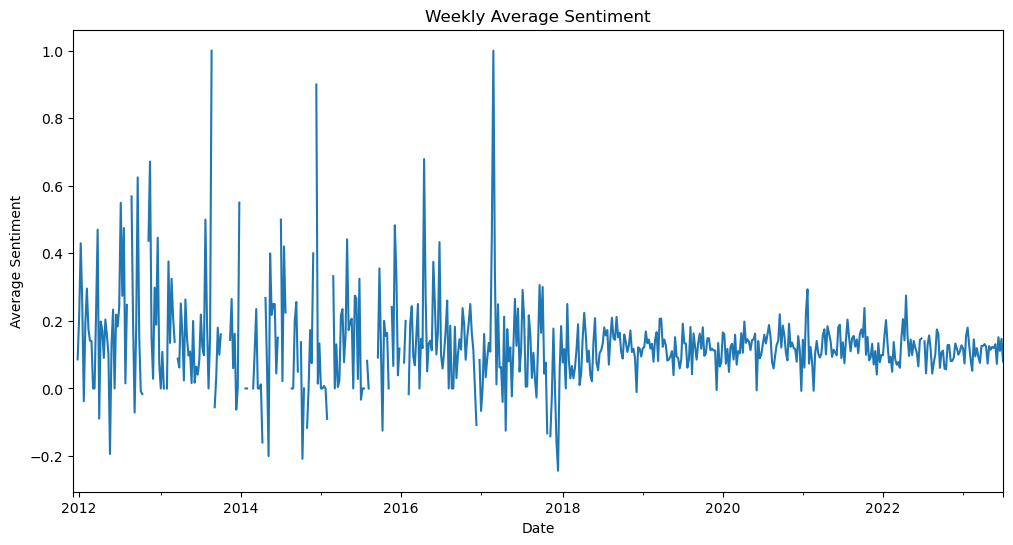

In [52]:
# Function to get sentiment polarity
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

# Apply the function to the 'content' column
DATA['sentiment'] = DATA['Text'].apply(get_sentiment)

# Plot sentiment over time
DATA['sentiment'].resample('W').mean().plot(figsize=(12, 6), title='Weekly Average Sentiment')
plt.xlabel('Date')
plt.ylabel('Average Sentiment')
plt.show()

In [54]:
print(DATA.head())

                      Datetime            Tweet Id  \
2011-12-01 2011-12-01 09:55:11  142179928203460608   
2011-12-01 2011-12-01 10:29:04  142188458125963264   
2011-12-21 2011-12-21 10:30:05  149436471764459520   
2011-12-21 2011-12-21 11:13:59  149447517325635584   
2011-12-21 2011-12-21 11:00:19  149444078210256896   

                                                         Text  Username  \
2011-12-01  Went to Iceland on Sat to ride bumper cars on ...  elonmusk   
2011-12-01  I made the volume on the Model S http://t.co/w...  elonmusk   
2011-12-21  Sam Harris also wrote a nice piece on the awes...  elonmusk   
2011-12-21  Yeah, this really is me, as my Mom @mayemusk w...  elonmusk   
2011-12-21  Got called randomly by Kanye West today and re...  elonmusk   

                                                 vader_scores  compound  \
2011-12-01  {'neg': 0.0, 'neu': 0.673, 'pos': 0.327, 'comp...    0.8932   
2011-12-01  {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...    0.0000   

In [102]:
# Take the first 1000 rows
DATA.to_csv('Project_300_DATASET.csv', index=True)  # `index=True` to keep the index in the CSV

In [58]:
#removing rows before Rivian had an initial public offering (IPO)
cutoff_date = pd.to_datetime('2021-11-10')

WORK = DATA[DATA.index >= cutoff_date]
print(WORK.head())

                      Datetime             Tweet Id  \
2021-11-10 2021-11-10 07:54:26  1458342271007473667   
2021-11-11 2021-11-10 17:16:16  1458483658071945223   
2021-11-11 2021-11-10 17:18:35  1458484242103640067   
2021-11-11 2021-11-10 17:38:24  1458489229571510279   
2021-11-11 2021-11-10 17:55:58  1458493650019749889   

                                                         Text  Username  \
2021-11-10  @Rainmaker1973 And that is a very tiny fractio...  elonmusk   
2021-11-11  @Tenjin37151 @Space_Station @SpaceX @Commercia...  elonmusk   
2021-11-11  @SawyerMerritt There are many other good cause...  elonmusk   
2021-11-11  @Rainmaker1973 Interestingly, however, average...  elonmusk   
2021-11-11                                  @Rainmaker1973 🔥🔥  elonmusk   

                                                 vader_scores  compound  \
2021-11-10  {'neg': 0.0, 'neu': 0.909, 'pos': 0.091, 'comp...    0.2732   
2021-11-11  {'neg': 0.047, 'neu': 0.738, 'pos': 0.215, 'co...    0.8

In [60]:
print(WORK.columns)

Index(['Datetime', 'Tweet Id', 'Text', 'Username', 'vader_scores', 'compound',
       'sentiment', 'RIVN', 'TSLA', '^GSPC'],
      dtype='object')


In [82]:
y=WORK['TSLA']
X=WORK.drop(['Datetime', 'Tweet Id', 'Text', 'Username','sentiment','TSLA','vader_scores'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=50)

In [84]:
print(X.dtypes)

compound    float64
RIVN        float64
^GSPC       float64
dtype: object


In [ ]:
#Trying multiple ML algorithms to see what works the best on our data

RandomForestRegressor(max_depth=1, n_estimators=1000, random_state=50)
Accuracy: 83.6 %.
Accuracy: 83.7 %.
RandomForestRegressor(max_depth=2, n_estimators=1000, random_state=50)
Accuracy: 86.5 %.
Accuracy: 86.5 %.
RandomForestRegressor(max_depth=3, n_estimators=1000, random_state=50)
Accuracy: 89.4 %.
Accuracy: 89.6 %.
RandomForestRegressor(max_depth=4, n_estimators=1000, random_state=50)
Accuracy: 90.8 %.
Accuracy: 90.9 %.
RandomForestRegressor(max_depth=5, n_estimators=1000, random_state=50)
Accuracy: 92.7 %.
Accuracy: 92.7 %.
RandomForestRegressor(max_depth=6, n_estimators=1000, random_state=50)
Accuracy: 94.1 %.
Accuracy: 94.1 %.
RandomForestRegressor(max_depth=7, n_estimators=1000, random_state=50)
Accuracy: 96.1 %.
Accuracy: 96.0 %.
RandomForestRegressor(max_depth=8, n_estimators=1000, random_state=50)
Accuracy: 97.5 %.
Accuracy: 97.4 %.
RandomForestRegressor(max_depth=9, n_estimators=1000, random_state=50)
Accuracy: 98.3 %.
Accuracy: 98.1 %.
RandomForestRegressor(max_depth=10, n

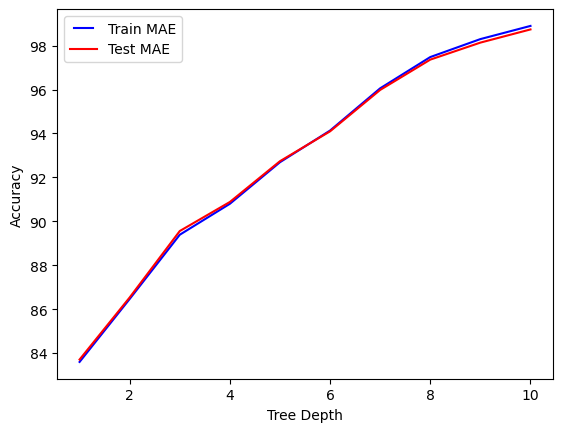

RandomForestRegressor(max_depth=4, n_estimators=1000, random_state=50)
Mean Absolute Error: 17.9 MW.
Accuracy: 90.9 %.


In [86]:
#Trying a random forest
max_depths = np.linspace(1, 10, 10, endpoint=True).astype(int)
train_results = []
test_results = []
for max_depth in max_depths:
    # Instantiate model with 1000 decision trees
    rf = RandomForestRegressor(n_estimators = 1000, random_state = 50, max_depth=max_depth)
    print(rf)

    # Train the model on training data
    rf.fit(X_train, y_train)

    # Use the RandomForestRegressor's predict method on the test data
    predictions_train = rf.predict(X_train)
    errors_train = abs(predictions_train- y_train)
    mape_train = 100 * (errors_train / y_train)
    accuracy_train = 100 - np.mean(mape_train)
    print('Accuracy:', round(accuracy_train, 1), '%.')
    train_results.append(accuracy_train)
    
    
    # Use the RandomForestRegressor's predict method on the test data
    predictions = rf.predict(X_test)
    errors = abs(predictions - y_test)
    mape = 100 * (errors / y_test)
    accuracy = 100 - np.mean(mape)
    print('Accuracy:', round(accuracy, 1), '%.')
    test_results.append(accuracy)
from matplotlib.legend_handler import HandlerLine2D
line1, = plt.plot(max_depths, train_results, 'b', label="Train MAE")
line2, = plt.plot(max_depths, test_results, 'r', label="Test MAE")
plt.legend(handler_map={line1: HandlerLine2D(numpoints=2)})
plt.ylabel('Accuracy')
plt.xlabel('Tree Depth')
plt.show()

from sklearn.ensemble import RandomForestRegressor

# Instantiate model with 1000 decision trees
rf = RandomForestRegressor(n_estimators = 1000, random_state = 50, max_depth=4)
print(rf)

# Train the model on training data
rf.fit(X_train, y_train)

# Use the RandomForestRegressor's predict method on the test data
predictions = rf.predict(X_test)
# Calculate the absolute errors
errors = abs(predictions - y_test)
# Print out the mean absolute error (mae)
print('Mean Absolute Error:', round(np.mean(errors), 1), 'MW.')

# Calculate mean absolute percentage error (MAPE)
mape = 100 * (errors / y_test)
# Calculate and display accuracy
accuracy = 100 - np.mean(mape)
print('Accuracy:', round(accuracy, 1), '%.')


This Random forest can fit this data fairly well, however it should be noted that this sample size is from November 10, 2021 to June 29 2023. This means that overfitting the data is likely to occur within the less than 500 days in the sample. The typical miss on the model is around $18.

In [92]:

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Mean Squared Error: 1538.545484516382
R^2 Score: 0.586030047736058
Intercept: -146.93176914903103
Coefficients: [1.40552987 1.34454324 0.0798182 ]


Within this model, Each Elon Musk tweet increases Tesla's stock price by $1.40, every dollar increase in Rivian's stock price increases Tesla's price by $1.34, every Dollar increase in the S&P 500 increases Tela's price by $0.08. However, the typical miss of this model is around $1538, meaning that the fit is not that great. Additionally, this model can only explain 58.6% of the variation in the price of tesla from the data provided. A better model would likely include long term competitors in the auto industry such as Toyota, Ford, or General Motors.

In order to see how this model works with a longer time frame, I remove the Rivian Column from the X variables.

In [94]:
#Retesting the model without Rivian to increase the sample size
y=DATA['TSLA']
X=DATA.drop(['Datetime', 'Tweet Id', 'Text', 'Username','sentiment','TSLA','vader_scores','RIVN'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=50)

In [96]:
print(X.dtypes)

compound    float64
^GSPC       float64
dtype: object


RandomForestRegressor(max_depth=1, n_estimators=1000, random_state=50)
Accuracy: 34.9 %.
Accuracy: 34.9 %.
RandomForestRegressor(max_depth=2, n_estimators=1000, random_state=50)
Accuracy: 58.1 %.
Accuracy: 58.2 %.
RandomForestRegressor(max_depth=3, n_estimators=1000, random_state=50)
Accuracy: 69.2 %.
Accuracy: 68.9 %.
RandomForestRegressor(max_depth=4, n_estimators=1000, random_state=50)
Accuracy: 78.2 %.
Accuracy: 77.6 %.
RandomForestRegressor(max_depth=5, n_estimators=1000, random_state=50)
Accuracy: 80.5 %.
Accuracy: 79.9 %.
RandomForestRegressor(max_depth=6, n_estimators=1000, random_state=50)
Accuracy: 82.3 %.
Accuracy: 81.4 %.
RandomForestRegressor(max_depth=7, n_estimators=1000, random_state=50)
Accuracy: 84.2 %.
Accuracy: 83.0 %.
RandomForestRegressor(max_depth=8, n_estimators=1000, random_state=50)
Accuracy: 86.0 %.
Accuracy: 84.6 %.
RandomForestRegressor(max_depth=9, n_estimators=1000, random_state=50)
Accuracy: 87.8 %.
Accuracy: 86.3 %.
RandomForestRegressor(max_depth=10, n

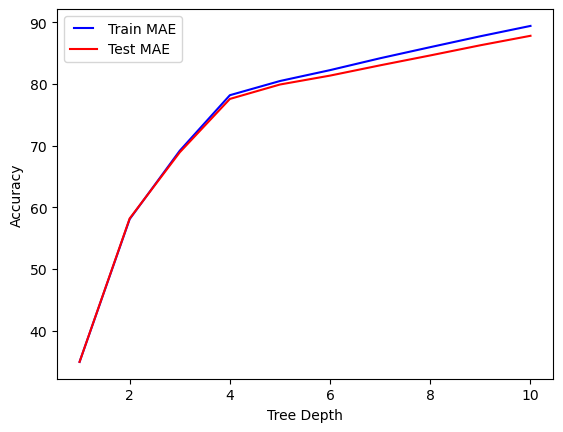

RandomForestRegressor(max_depth=4, n_estimators=1000, random_state=50)
Mean Absolute Error: 20.8 MW.
Accuracy: 77.6 %.


In [98]:
#Trying a random forest
max_depths = np.linspace(1, 10, 10, endpoint=True).astype(int)
train_results = []
test_results = []
for max_depth in max_depths:
    # Instantiate model with 1000 decision trees
    rf = RandomForestRegressor(n_estimators = 1000, random_state = 50, max_depth=max_depth)
    print(rf)

    # Train the model on training data
    rf.fit(X_train, y_train)

    # Use the RandomForestRegressor's predict method on the test data
    predictions_train = rf.predict(X_train)
    errors_train = abs(predictions_train- y_train)
    mape_train = 100 * (errors_train / y_train)
    accuracy_train = 100 - np.mean(mape_train)
    print('Accuracy:', round(accuracy_train, 1), '%.')
    train_results.append(accuracy_train)
    
    
    # Use the RandomForestRegressor's predict method on the test data
    predictions = rf.predict(X_test)
    errors = abs(predictions - y_test)
    mape = 100 * (errors / y_test)
    accuracy = 100 - np.mean(mape)
    print('Accuracy:', round(accuracy, 1), '%.')
    test_results.append(accuracy)
from matplotlib.legend_handler import HandlerLine2D
line1, = plt.plot(max_depths, train_results, 'b', label="Train MAE")
line2, = plt.plot(max_depths, test_results, 'r', label="Test MAE")
plt.legend(handler_map={line1: HandlerLine2D(numpoints=2)})
plt.ylabel('Accuracy')
plt.xlabel('Tree Depth')
plt.show()

from sklearn.ensemble import RandomForestRegressor

# Instantiate model with 1000 decision trees
rf = RandomForestRegressor(n_estimators = 1000, random_state = 50, max_depth=4)
print(rf)

# Train the model on training data
rf.fit(X_train, y_train)

# Use the RandomForestRegressor's predict method on the test data
predictions = rf.predict(X_test)
# Calculate the absolute errors
errors = abs(predictions - y_test)
# Print out the mean absolute error (mae)
print('Mean Absolute Error:', round(np.mean(errors), 1), 'MW.')

# Calculate mean absolute percentage error (MAPE)
mape = 100 * (errors / y_test)
# Calculate and display accuracy
accuracy = 100 - np.mean(mape)
print('Accuracy:', round(accuracy, 1), '%.')


With this longer time frame I'm less concerned about overfitting, but the typical miss of the model is still around $20.8 for a random forest, additionally the model starts overfitting after depth of 4.

In [100]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Mean Squared Error: 2276.5048751411628
R^2 Score: 0.7984983001864061
Intercept: -278.49822835087934
Coefficients: [-0.46005539  0.12024352]


This simpler model with just the S&P and the sentiment scores from his tweets show that basically anytime Elon Musk tweets Tesla's Stock Price decreases by .46, and as the S&P increases by 1, Tesla's Price only increases by .12. The typical miss within this model is around 2276, but it can explain 79.8% of the variation in Tesla Price. 

Ultimately if a longer time period of data were to be available for Rivian and Tesla, I would bet that the linear regression model would provide a sufficent method to see how Elon Musk's tweets affect Tesla's price. 